### Installing Required Libraries


In [ ]:
!pip install lime
!pip install datasets

### Importing Libraries and Setting Up Environment


In [3]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from tqdm import tqdm  
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset, Dataset
import shap
import lime
import lime.lime_text
import lime.lime_tabular
import matplotlib.pyplot as plt
import seaborn as sns

# from google.colab import drive
# drive.mount('/content/drive')

import warnings
warnings.filterwarnings('ignore')


# Set seaborn style
sns.set_style("whitegrid")  # Clean, modern grid style

# Set font scale for better readability
sns.set_context("notebook", font_scale=1.2)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Loading the DiverseVul Dataset


In [10]:
# Load the DiverseVul dataset
df = pd.read_csv("/kaggle/input/diversevul-dataset/diversevul.csv").dropna()
df['target'] = df['target'].astype(int)
df.head()

,func,target,cwe,project,commit_id,hash,size,message
0,int _gnutls_ciphertext2compressed(gnutls_sessi...,1,[],gnutls,7ad6162573ba79a4392c63b453ad0220ca6c5ace,7.300865e+37,157.0,added an extra check while checking the padding.
1,static char *make_filename_safe(const char *fi...,1,['CWE-264'],php-src,055ecbc62878e86287d742c7246c21606cee8183,2.118242e+38,22.0,Improve check for :memory: pseudo-filename in ...
2,"unpack_Z_stream(int fd_in, int fd_out)\n{\n\tI...",1,[],busybox,251fc70e9722f931eec23a34030d05ba5f747b0e,2.140171e+37,232.0,uncompress: fix buffer underrun by corrupted i...
3,"static void cirrus_do_copy(CirrusVGAState *s, ...",1,['CWE-787'],qemu,b2eb849d4b1fdb6f35d5c46958c7f703cf64cfef,1.355909e+38,66.0,"CVE-2007-1320 - Cirrus LGD-54XX ""bitblt"" heap ..."
4,"glue(cirrus_bitblt_rop_fwd_, ROP_NAME)(CirrusV...",1,['CWE-787'],qemu,b2eb849d4b1fdb6f35d5c46958c7f703cf64cfef,2.769639e+37,18.0,"CVE-2007-1320 - Cirrus LGD-54XX ""bitblt"" heap ..."


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32210 entries, 0 to 32232
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   func       32210 non-null  object 
 1   target     32210 non-null  int64  
 2   cwe        32210 non-null  object 
 3   project    32210 non-null  object 
 4   commit_id  32210 non-null  object 
 5   hash       32210 non-null  float64
 6   size       32210 non-null  float64
 7   message    32210 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 2.2+ MB


### Visualizing Target Distribution in the DiverseVul Dataset


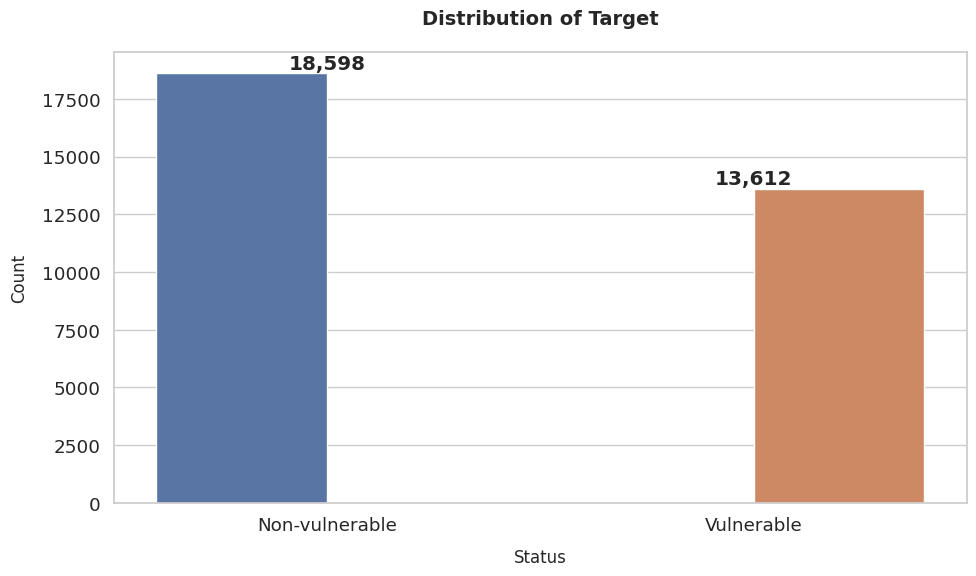

In [12]:
# Calculate value counts
value_counts = df['target'].value_counts()

# Create a mapping dictionary
target_names = {0: 'Non-vulnerable', 1: 'Vulnerable'}

# Create bar plot with mapped labels
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=[target_names[i] for i in value_counts.index],
                y=value_counts.values,
                palette="deep",
                hue=[target_names[i] for i in value_counts.index],
                )

# Set labels and title
plt.xlabel('Status', labelpad=10, fontsize=12)
plt.ylabel('Count', labelpad=10, fontsize=12)

# Add value labels on top of each bar
for i, v in enumerate(value_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Customize the plot
plt.title('Distribution of Target', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Status', labelpad=10, fontsize=12)
plt.ylabel('Count', labelpad=10, fontsize=12)

# Adjust layout
plt.tight_layout()

# Disable legend
plt.legend([],[], frameon=False)

# Show the plot
plt.show()

### Balancing Dataset and Visualizing Target Distribution


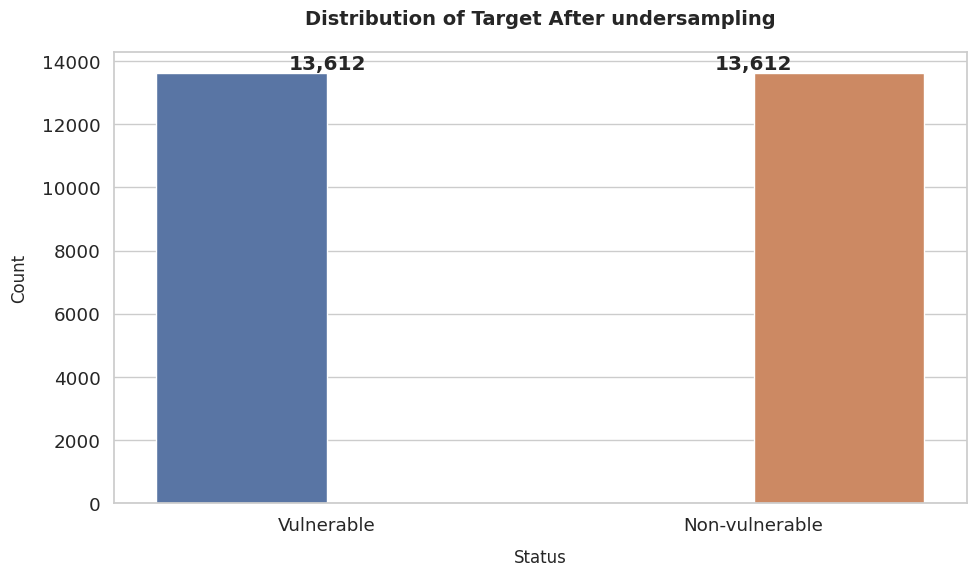

In [13]:
vulnerable = df[df['target'] == 1]
non_vulnerable = df[df['target'] == 0]
non_vulnerable = non_vulnerable.sample(n=len(vulnerable), random_state=42)

balanced_df = pd.concat([vulnerable, non_vulnerable])

# Calculate value counts
value_counts = balanced_df['target'].value_counts()

# Create a mapping dictionary
target_names = {0: 'Non-vulnerable', 1: 'Vulnerable'}

# Create bar plot with mapped labels
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=[target_names[i] for i in value_counts.index],
                y=value_counts.values,
                palette="deep",
                hue=[target_names[i] for i in value_counts.index],
                )

# Set labels and title
plt.xlabel('Status', labelpad=10, fontsize=12)
plt.ylabel('Count', labelpad=10, fontsize=12)

# Add value labels on top of each bar
for i, v in enumerate(value_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Customize the plot
plt.title('Distribution of Target After undersampling', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Status', labelpad=10, fontsize=12)
plt.ylabel('Count', labelpad=10, fontsize=12)

# Adjust layout
plt.tight_layout()

# Disable legend
plt.legend([],[], frameon=False)

# Show the plot
plt.show()

### Tokenizing the Dataset for BERT Model


In [14]:

# Preprocess the dataset (tokenization)
def preprocess_data(balanced_df, tokenizer, max_length=512):
    """
    Preprocess the dataset.
    Args:
        df (pd.DataFrame): The dataset.
        tokenizer (BertTokenizer): BERT tokenizer.
        max_length (int): Maximum sequence length.
    Returns:
        dict: Tokenized inputs and labels.
    """

    # Convert the balanced DataFrame to a Hugging Face Dataset
    dataset = Dataset.from_pandas(balanced_df)

    # Tokenize the dataset in parallel
    def tokenize_function(examples):
        return tokenizer(examples['func'], truncation=True, padding='max_length', max_length=max_length)

    tokenized_dataset = dataset.map(tokenize_function, batched=True, num_proc=4)  # Use 4 CPU cores

    # Convert tokenized dataset to PyTorch tensors
    encodings = {
        'input_ids': torch.tensor(tokenized_dataset['input_ids']),
        'attention_mask': torch.tensor(tokenized_dataset['attention_mask'])
    }
    labels = torch.tensor(tokenized_dataset['target'])

    return encodings, labels

# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Preprocess the dataset
encodings, labels = preprocess_data(balanced_df, tokenizer)

Map (num_proc=4):   0%|          | 0/27224 [00:00<?, ? examples/s]

### Splitting the Dataset into Training and Testing Sets


In [15]:

# Split the indices first
indices = np.arange(len(labels))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42
)

# Use the indices to split both labels and encodings
train_labels = labels[train_idx]
test_labels = labels[test_idx]

train_encodings = {
    'input_ids': encodings['input_ids'][train_idx],
    'attention_mask': encodings['attention_mask'][train_idx]
}

test_encodings = {
    'input_ids': encodings['input_ids'][test_idx],
    'attention_mask': encodings['attention_mask'][test_idx]
}

print(f"Train dataset size: {len(train_labels)}")
print(f"Test dataset size: {len(test_labels)}")


Train dataset size: 21779
Test dataset size: 5445


### Creating Custom PyTorch Dataset for Model Training


In [16]:

# Custom dataset class for PyTorch
class CodeDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

# Create PyTorch datasets
train_dataset = CodeDataset(train_encodings, train_labels)
test_dataset = CodeDataset(test_encodings, test_labels)

### Fine-Tuning BERT Model


In [17]:
num_train_epochs=5

output_dir='./results'

# Load the pre-trained BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2).to(device)

# Define training arguments
training_args = TrainingArguments(
    output_dir=output_dir,              # Output directory
    num_train_epochs=num_train_epochs,  # Number of training epochs
    per_device_train_batch_size=16,     # Batch size for training
    per_device_eval_batch_size=64,      # Batch size for evaluation
    warmup_steps=500,                   # Number of warmup steps
    weight_decay=0.01,                  # Strength of weight decay
    logging_dir='./logs',               # Directory for storing logs
    logging_steps=10,                   # Log every 10 steps
    eval_strategy="epoch",              # Evaluate every epoch
    save_strategy="epoch",              # Save model every epoch
    load_best_model_at_end=True,        # Load the best model at the end
    fp16=True,                          # Enable mixed precision training
    dataloader_pin_memory=True,         # Enable pin memory
    report_to="none",                   # Disable reporting
)


# Function to compute metrics for evaluation
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Initialize the Trainer
trainer = Trainer(
    model=model,                         # The pre-trained model
    args=training_args,                  # Training arguments
    train_dataset=train_dataset,         # Training dataset
    eval_dataset=test_dataset,           # Evaluation dataset
    compute_metrics=compute_metrics,     # Function to compute metrics
)

# Fine-tune the model
trainer.train()

# Evaluate the model
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

# Save the trained model
model_path = "./trained_model"
model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.810100,0.473179,0.799816,0.820959,0.744415,0.915049
2,0.380100,0.439321,0.813223,0.835090,0.749418,0.942878
3,0.384600,0.418828,0.820202,0.837780,0.765133,0.925668


Evaluation results: {'eval_loss': 0.41882801055908203, 'eval_accuracy': 0.8202020202020202, 'eval_f1': 0.8377796188898093, 'eval_precision': 0.7651331719128329, 'eval_recall': 0.9256682533870377, 'eval_runtime': 81.5407, 'eval_samples_per_second': 66.776, 'eval_steps_per_second': 1.055, 'epoch': 3.0}


('./trained_model/tokenizer_config.json',
 './trained_model/special_tokens_map.json',
 './trained_model/vocab.txt',
 './trained_model/added_tokens.json')

### Model Evaluation


Getting predictions for the train dataset...


Processing Batches: 100%|██████████| 681/681 [05:31<00:00,  2.06it/s]


Getting predictions for the test dataset...


Processing Batches: 100%|██████████| 171/171 [01:22<00:00,  2.06it/s]


Train Dataset Metrics:
Accuracy: 0.8520
Precision: 0.7925
Recall: 0.9533
F1-Score: 0.8655

Test Dataset Metrics:
Accuracy: 0.8202
Precision: 0.7651
Recall: 0.9257
F1-Score: 0.8378



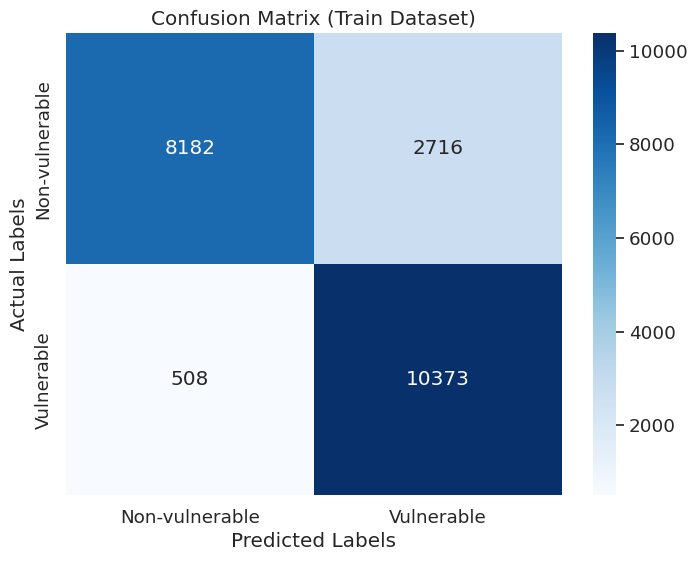

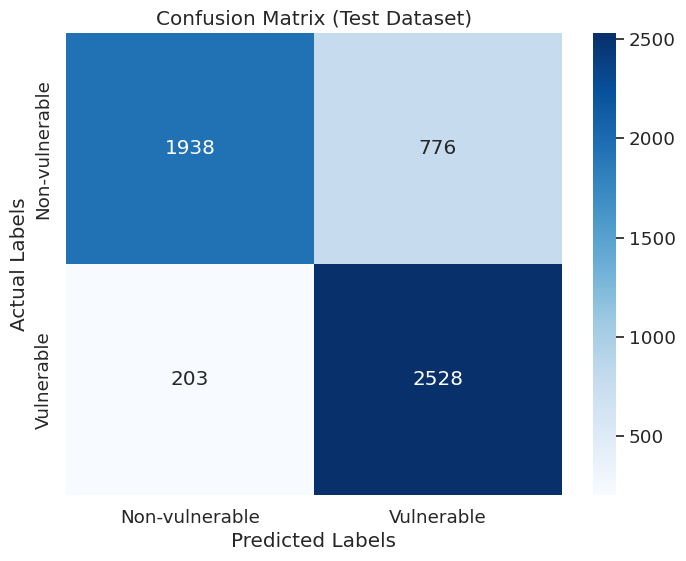

In [18]:
# Load the fine-tuned model and tokenizer
model_path = "./trained_model"
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path).to(device)

# Ensure the model is in evaluation mode
model.eval()

# function to get predictions in batches with tqdm
def get_predictions_batch(model, dataset, batch_size=32):
    model.eval()
    predictions = []
    with torch.no_grad():
        # Use DataLoader to handle batching automatically
        from torch.utils.data import DataLoader

        dataloader = DataLoader(dataset, batch_size=batch_size)
        for batch in tqdm(dataloader, desc="Processing Batches"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1).cpu().tolist()
            predictions.extend(preds)
    return predictions

# Get predictions for the train dataset with progress bar
print("Getting predictions for the train dataset...")
train_predictions = get_predictions_batch(model, train_dataset)

# Get actual labels for the train dataset
train_actual_labels = train_labels.numpy()

# Generate the confusion matrix for the train dataset
train_conf_matrix = confusion_matrix(train_actual_labels, train_predictions)

# Calculate evaluation metrics for the train dataset
train_accuracy = accuracy_score(train_actual_labels, train_predictions)
train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
    train_actual_labels, train_predictions, average='binary'
)

# Get predictions for the test dataset with progress bar
print("Getting predictions for the test dataset...")
predictions = get_predictions_batch(model, test_dataset)

# Get actual labels
actual_labels = test_labels.numpy()

# Generate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predictions)

# Calculate evaluation metrics
accuracy = accuracy_score(actual_labels, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(actual_labels, predictions, average='binary')

# Print results
print(f"Train Dataset Metrics:")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall: {train_recall:.4f}")
print(f"F1-Score: {train_f1:.4f}\n")

print(f"Test Dataset Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}\n")

# Plot the confusion matrix for the train dataset
plt.figure(figsize=(8, 6))
sns.heatmap(train_conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-vulnerable', 'Vulnerable'], 
            yticklabels=['Non-vulnerable', 'Vulnerable'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix (Train Dataset)')
plt.show()

# Plot the confusion matrix for the test dataset
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-vulnerable', 'Vulnerable'], 
            yticklabels=['Non-vulnerable', 'Vulnerable'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix (Test Dataset)')
plt.show()


### How to Classify a New Code Sample Using the Fine-Tuned Model


In [20]:
# Function to classify a single code sample and get probabilities
def classify_code_sample(code_sample, model, tokenizer, max_length=512):
    # Tokenize the input code sample
    inputs = tokenizer(
        code_sample,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors="pt"
    ).to(device)

    # Get model predictions (logits)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    # Apply softmax to get probabilities
    probabilities = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

    return probabilities

# Example code sample
code_sample = """
TEST_F(ConnectionHandlerTest, CloseDuringFilterChainCreate) {\n  InSequence s;\n\n  Network::MockListener* listener = new Network::MockListener();\n  Network::ListenerCallbacks* listener_callbacks;\n  TestListener* test_listener = addListener(1, true, false, "test_listener");\n  EXPECT_CALL(dispatcher_, createListener_(_, _, _))\n      .WillOnce(\n          Invoke([&](Network::Socket&, Network::ListenerCallbacks& cb, bool) -> Network::Listener* {\n            listener_callbacks = &cb;\n            return listener;\n          }));\n  EXPECT_CALL(test_listener->socket_, localAddress());\n  handler_->addListener(*test_listener);\n\n  EXPECT_CALL(manager_, findFilterChain(_)).WillOnce(Return(filter_chain_.get()));\n  Network::MockConnection* connection = new NiceMock<Network::MockConnection>();\n  EXPECT_CALL(dispatcher_, createServerConnection_()).WillOnce(Return(connection));\n  EXPECT_CALL(factory_, createNetworkFilterChain(_, _)).WillOnce(Return(true));\n  EXPECT_CALL(*connection, state()).WillOnce(Return(Network::Connection::State::Closed));\n  EXPECT_CALL(*connection, addConnectionCallbacks(_)).Times(0);\n  Network::MockConnectionSocket* accepted_socket = new NiceMock<Network::MockConnectionSocket>();\n  listener_callbacks->onAccept(Network::ConnectionSocketPtr{accepted_socket});\n  EXPECT_EQ(0UL, handler_->numConnections());\n\n  EXPECT_CALL(*listener, onDestroy());\n}
"""

# Classify the code sample and get probabilities
probabilities = classify_code_sample(code_sample, model, tokenizer)

# Determine the predicted class
class_names = ["Non-vulnerable", "Vulnerable"]
predicted_class_index = probabilities.argmax()  # Index of the class with the highest probability
predicted_class = class_names[predicted_class_index]

# Print the predicted class
print(f"Predicted Class: {predicted_class}")

# Print the probabilities for each class
for class_name, prob in zip(class_names, probabilities):
    print(f"Probability of {class_name}: {prob:.4f}")

Predicted Class: Vulnerable
Probability of Non-vulnerable: 0.2282
Probability of Vulnerable: 0.7718


### Model Interpretability and Explanation using SHAP, LIME, and Attention Heatmaps

Starting model explanation analysis...
Generating SHAP explanations...


  0%|          | 0/498 [00:00<?, ?it/s]

<Figure size 1500x500 with 0 Axes>

Generating LIME explanations...


<Figure size 1000x600 with 0 Axes>

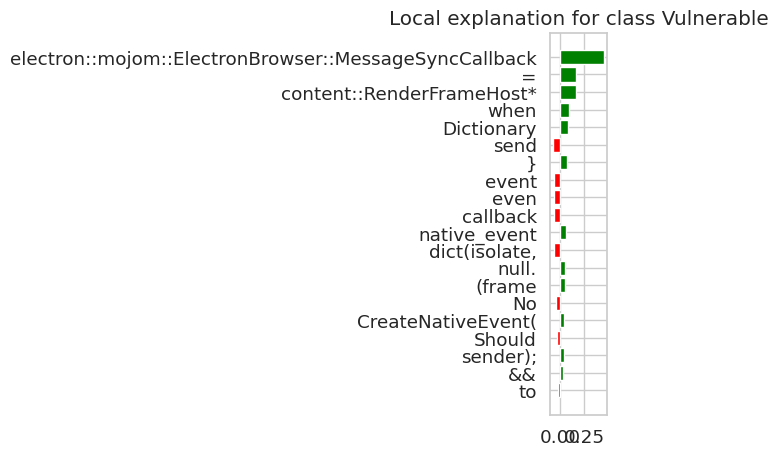

Generating attention heatmap...


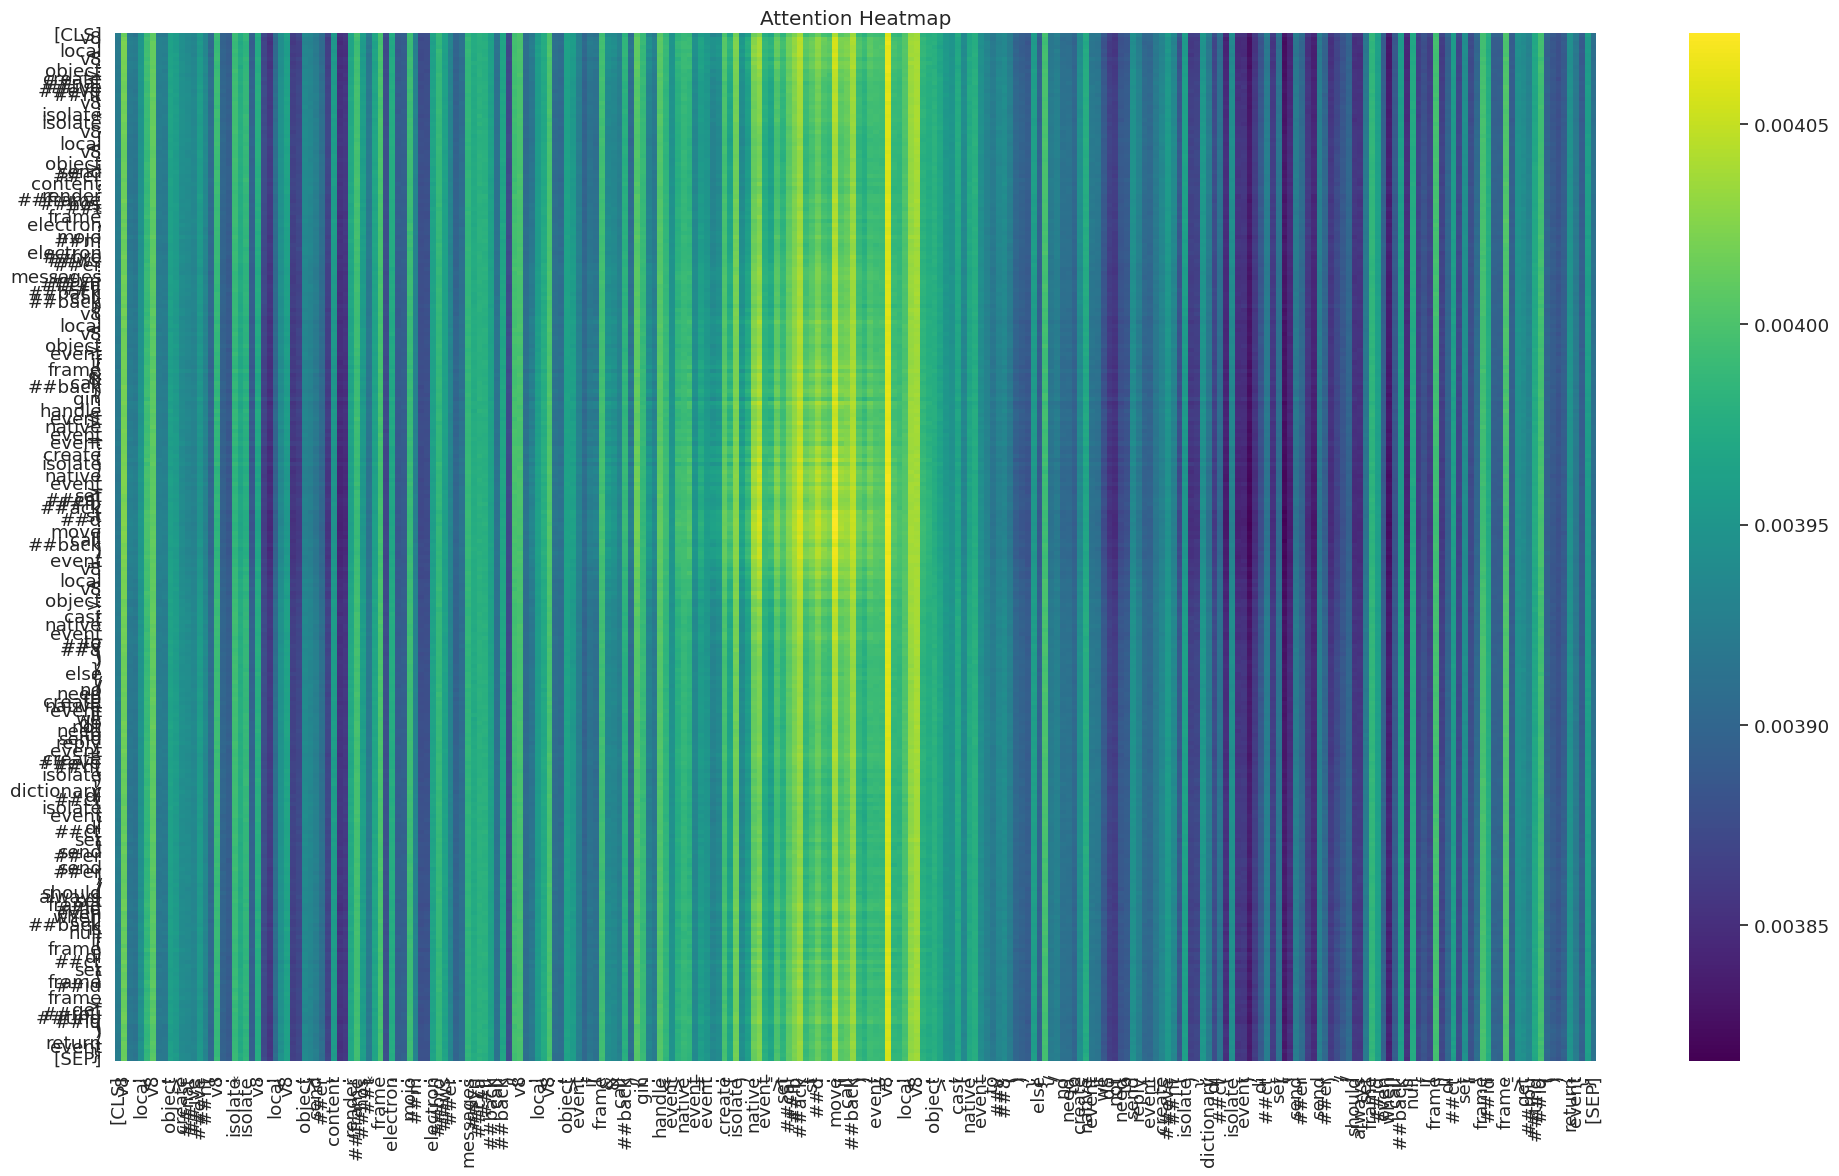

Analysis complete!


In [26]:

def explain_with_shap(model, tokenizer, sample_texts):
    """
    Explain model predictions using SHAP.
    """
    model.eval()

    def predict(texts):
        # Handle single text input
        if isinstance(texts, str):
            texts = [texts]

        # Ensure all texts are strings
        texts = [str(text) for text in texts]

        try:
            inputs = tokenizer(
                texts,
                padding=True,
                truncation=True,
                max_length=512,  # Limit to model's max length
                return_tensors="pt"
            ).to(device)

            with torch.no_grad():
                outputs = model(**inputs)
            return outputs.logits.cpu().numpy()
        except Exception as e:
            print(f"Error in prediction: {str(e)}")
            return None

    # Create explainer with proper prediction function
    explainer = shap.Explainer(
        predict,
        tokenizer,
        output_names=['Non-Vulnerable', 'Vulnerable']
    )

    # Calculate and plot SHAP values
    for text in sample_texts:
        try:
            # Ensure text is string and truncate if needed
            text = str(text)
            if len(text) > 1500:  # Approximate character limit
                text = text[:1500]

            shap_values = explainer([text])
            plt.figure(figsize=(15, 5))
            shap.plots.text(shap_values[0])
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Error generating SHAP explanation: {str(e)}")

def explain_with_lime(model, tokenizer, sample_texts):
    """
    Explain model predictions using LIME.
    """
    model.eval()

    def predict_proba(texts):
        # Handle single text input
        if isinstance(texts, str):
            texts = [texts]

        # Ensure all texts are strings
        texts = [str(text) for text in texts]

        try:
            inputs = tokenizer(
                texts,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors="pt"
            ).to(device)

            with torch.no_grad():
                outputs = model(**inputs)
                probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            return probs.cpu().numpy()
        except Exception as e:
            print(f"Error in prediction: {str(e)}")
            return None

    # Use LIME text explainer
    explainer = lime.lime_text.LimeTextExplainer(
        class_names=['Non-Vulnerable', 'Vulnerable'],
        split_expression=lambda x: x.split()  # Split by whitespace for code
    )

    for text in sample_texts:
        try:
            # Ensure text is string and truncate if needed
            text = str(text)
            if len(text) > 1500:  # Approximate character limit
                text = text[:1500]

            exp = explainer.explain_instance(
                text,
                predict_proba,
                num_features=20,
                num_samples=100
            )
            plt.figure(figsize=(10, 6))
            exp.as_pyplot_figure()
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Error generating LIME explanation: {str(e)}")

def plot_attention_heatmap(model, tokenizer, sample_text):
    """
    Plot attention heatmap.
    """
    model.eval()

    try:
        # Ensure text is string and truncate if needed
        sample_text = str(sample_text)
        if len(sample_text) > 1500:  # Approximate character limit
            sample_text = sample_text[:1500]

        inputs = tokenizer(
            sample_text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=512,
            add_special_tokens=True
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs, output_attentions=True)

        # Get attention weights from last layer
        attention = outputs.attentions[-1].squeeze(0)
        attention_avg = attention.mean(dim=0).cpu().numpy()

        # Get tokens for visualization
        tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

        # Plot heatmap
        plt.figure(figsize=(20, 12))
        sns.heatmap(
            attention_avg,
            xticklabels=tokens,
            yticklabels=tokens,
            cmap="viridis"
        )
        plt.title("Attention Heatmap")
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error generating attention heatmap: {str(e)}")

def analyze_model_explanations(model, tokenizer, df, num_samples=5):
    """
    Run all explanability methods with proper error handling.
    """
    try:
        # Convert to string and filter out None values
        df = df.copy()
        df['func'] = df['func'].astype(str)
        df = df[df['func'].str.len() > 0]

        # Sample texts
        sample_texts = df['func'].sample(n=min(num_samples, len(df)),random_state=42).tolist()

        print("Generating SHAP explanations...")
        explain_with_shap(model, tokenizer, sample_texts)

        print("Generating LIME explanations...")
        explain_with_lime(model, tokenizer, sample_texts)

        print("Generating attention heatmap...")
        plot_attention_heatmap(model, tokenizer, sample_texts[0])

    except Exception as e:
        print(f"Error in analysis: {str(e)}")

# Usage
def get_model_explanations(trainer, tokenizer, df, num_samples=5):
    """
    Wrapper function to analyze model predictions.
    """
    try:
        print("Starting model explanation analysis...")
        analyze_model_explanations(trainer.model, tokenizer, df, num_samples)
        print("Analysis complete!")
    except Exception as e:
        print(f"Error during analysis: {str(e)}")

# After training your model
get_model_explanations(trainer, tokenizer, df, num_samples=1)  

In [22]:
import shutil

# Zip the directory
zip_path = "./trained_model.zip"
shutil.make_archive(base_name=model_path, format="zip", root_dir=model_path)

print(f"Model directory zipped to: {zip_path}")


Model directory zipped to: ./trained_model.zip
